#  Unemployment Analysis in India

This notebook provides a comprehensive analysis of unemployment trends in India, examining regional variations, seasonal patterns, and correlations with employment and labour participation rates.

**Analysis Topics:**
- Data loading and cleaning
- Regional and temporal aggregation
- Time series trend analysis
- Employment and unemployment relationships
- Rural vs urban comparisons

In [59]:
#Importing libraries
import kaggle
import pandas as pd
import numpy as np
from kaggle.api.kaggle_api_extended import KaggleApi

In [61]:
api = KaggleApi()
api.authenticate()
handle = 'gokulrajkmv/unemployment-in-india'

api.dataset_download_files(handle,path = './',unzip = True)

Dataset URL: https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india


In [62]:
#Loading the dataset
unemp = pd.read_csv('Unemployment in India.csv')
unemp.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [63]:
#Loading supplimentary data

unemp_2020 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
unemp_2020.head(2)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74


In [64]:
#Statistical summary
print(unemp.shape)
print(unemp.info())

print(unemp_2020.shape)
print(unemp_2020.info())

(768, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None
(267, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  -

## Step 1: Data Cleaning & Preprocessing

In [65]:
#Chacking for NA values
print(unemp.isnull().any())
print(unemp_2020.isnull().any)

Region                                      True
 Date                                       True
 Frequency                                  True
 Estimated Unemployment Rate (%)            True
 Estimated Employed                         True
 Estimated Labour Participation Rate (%)    True
Area                                        True
dtype: bool
<bound method DataFrame.any of      Region   Date   Frequency   Estimated Unemployment Rate (%)  \
0     False  False       False                             False   
1     False  False       False                             False   
2     False  False       False                             False   
3     False  False       False                             False   
4     False  False       False                             False   
..      ...    ...         ...                               ...   
262   False  False       False                             False   
263   False  False       False                             False   
26

In [66]:

print(unemp.isnull().sum())
print(unemp_2020.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


In [67]:
 #Checking the rows with null values
unemp[unemp.isnull().any(axis = 1)]


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
#Droping the NULL values
unemp.dropna(inplace= True)
unemp.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [69]:
unemp['Region'].value_counts()

Region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Uttarakhand         27
Meghalaya           27
Assam               26
Puducherry          26
Goa                 24
Jammu & Kashmir     21
Sikkim              17
Chandigarh          12
Name: count, dtype: int64

In [70]:
#Convert date strings to datetime objects
unemp.columns = unemp.columns.str.strip()
unemp_2020.columns = unemp_2020.columns.str.strip()
unemp.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [71]:
unemp['Date'] = unemp['Date'].astype(str).str.strip()
unemp_2020['Date'] = unemp_2020['Date'].astype(str).str.strip()

unemp['Date'] = pd.to_datetime(unemp['Date'], format='%d-%m-%Y', errors='coerce')
unemp['Date'] = pd.to_datetime(unemp_2020['Date'], format='%d-%m-%Y', errors='coerce')

In [72]:
unemp['Date'] = pd.to_datetime(unemp['Date'],format = '%d-%m-%Y')
unemp['Month_int'] = unemp['Date'].dt.month
unemp['Month'] = unemp['Date'].dt.strftime("%B")

#Remove the frequency columns
unemp.drop('Frequency',axis = 1,inplace = True)
unemp.head(4)

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month_int,Month
0,Andhra Pradesh,2020-01-31,3.65,11999139.0,43.24,Rural,1.0,January
1,Andhra Pradesh,2020-02-29,3.05,11755881.0,42.05,Rural,2.0,February
2,Andhra Pradesh,2020-03-31,3.75,12086707.0,43.50,Rural,3.0,March
3,Andhra Pradesh,2020-04-30,3.32,12285693.0,43.97,Rural,4.0,April


In [73]:
unemp_2020['Date'] = pd.to_datetime(unemp_2020['Date'],format = '%d-%m-%Y')
unemp_2020['Month_int'] = unemp_2020['Date'].dt.month
unemp_2020['Month'] = unemp_2020['Date'].dt.strftime("%B")

#Drop some columns
unemp_2020.drop(['Frequency','longitude','latitude','Region.1'],axis = 1,inplace = True)

unemp_2020.head(4)

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Month_int,Month
0,Andhra Pradesh,2020-01-31,5.48,16635535,41.02,1,January
1,Andhra Pradesh,2020-02-29,5.83,16545652,40.90,2,February
2,Andhra Pradesh,2020-03-31,5.79,15881197,39.18,3,March
3,Andhra Pradesh,2020-04-30,20.51,11336911,33.10,4,April


## Step 2: Combining Datasets

In [74]:
combined_unemp = pd.concat([unemp,unemp_2020],ignore_index = True)
combined_unemp.head()

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month_int,Month
0,Andhra Pradesh,2020-01-31,3.65,11999139.0,43.24,Rural,1.0,January
1,Andhra Pradesh,2020-02-29,3.05,11755881.0,42.05,Rural,2.0,February
2,Andhra Pradesh,2020-03-31,3.75,12086707.0,43.50,Rural,3.0,March
3,Andhra Pradesh,2020-04-30,3.32,12285693.0,43.97,Rural,4.0,April
4,Andhra Pradesh,2020-05-31,5.17,12256762.0,44.68,Rural,5.0,May


## Step 3: Data Aggregation & Statistical Analysis

### Aggregating by Region

In [75]:
unemp_by_region_sum = combined_unemp.groupby("Region")['Estimated Unemployment Rate (%)'].sum().sort_values(ascending = False)

unemp_by_region_mean = combined_unemp.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending = False)

unemp_by_region_min = combined_unemp.groupby("Region")["Estimated Unemployment Rate (%)"].min()

unemp_by_region_max = combined_unemp.groupby("Region")["Estimated Unemployment Rate (%)"].max()

print("The sum of unemployment  by region is:")
print(unemp_by_region_sum.head(5))
print('\n'+ '='*50 + '\n')
print("The average unemployment by region is:")
print(unemp_by_region_mean.head(5))

The sum of unemployment  by region is:
Region
Tripura             1044.36
Haryana             1010.70
Jharkhand            771.77
Bihar                724.42
Himachal Pradesh     679.78
Name: Estimated Unemployment Rate (%), dtype: float64


The average unemployment by region is:
Region
Tripura             27.483158
Haryana             26.597368
Jharkhand           20.309737
Bihar               19.063684
Himachal Pradesh    17.888947
Name: Estimated Unemployment Rate (%), dtype: float64


### Aggregating by Month

In [76]:
unemp_by_months_sum = combined_unemp.groupby("Month")['Estimated Unemployment Rate (%)'].sum().sort_values(ascending = False)

unemp_by_months_mean = combined_unemp.groupby("Month")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending = False)

unemp_by_months_min = combined_unemp.groupby("Month")["Estimated Unemployment Rate (%)"].min()

unemp_by_months_max = combined_unemp.groupby("Month")["Estimated Unemployment Rate (%)"].max()

print("The sum of unemployment  by region is:")
print(unemp_by_months_sum.head(5))
print('\n'+ '='*50 + '\n')
print("The average unemployment by region is:")
print(unemp_by_months_mean.head(5))

The sum of unemployment  by region is:
Month
May          867.46
April        798.00
June         646.05
August       596.80
September    563.23
Name: Estimated Unemployment Rate (%), dtype: float64


The average unemployment by region is:
Month
May          16.064074
April        15.346154
June         11.963889
August       11.051852
September    10.430185
Name: Estimated Unemployment Rate (%), dtype: float64


## Step 4: Data Visualization & Exploratory Analysis

### Unemployment by Region

C:\Users\levie\AppData\Local\Temp\ipykernel_6372\3813803339.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




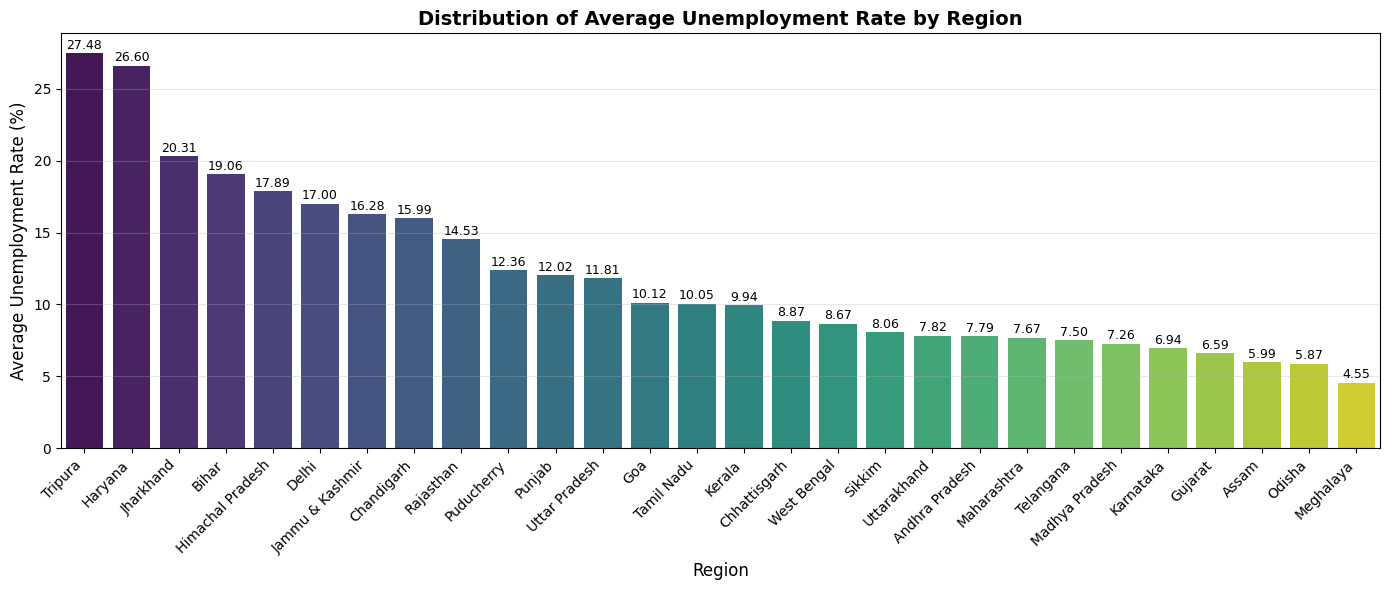

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create bar graph for unemployment distribution by region
plt.figure(figsize=(14, 6))
sns.barplot(
    x=unemp_by_region_mean.index,
    y=unemp_by_region_mean.values,
    palette='viridis'
)

plt.title('Distribution of Average Unemployment Rate by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(unemp_by_region_mean.values):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Unemployment by Month

C:\Users\levie\AppData\Local\Temp\ipykernel_6372\2013740702.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




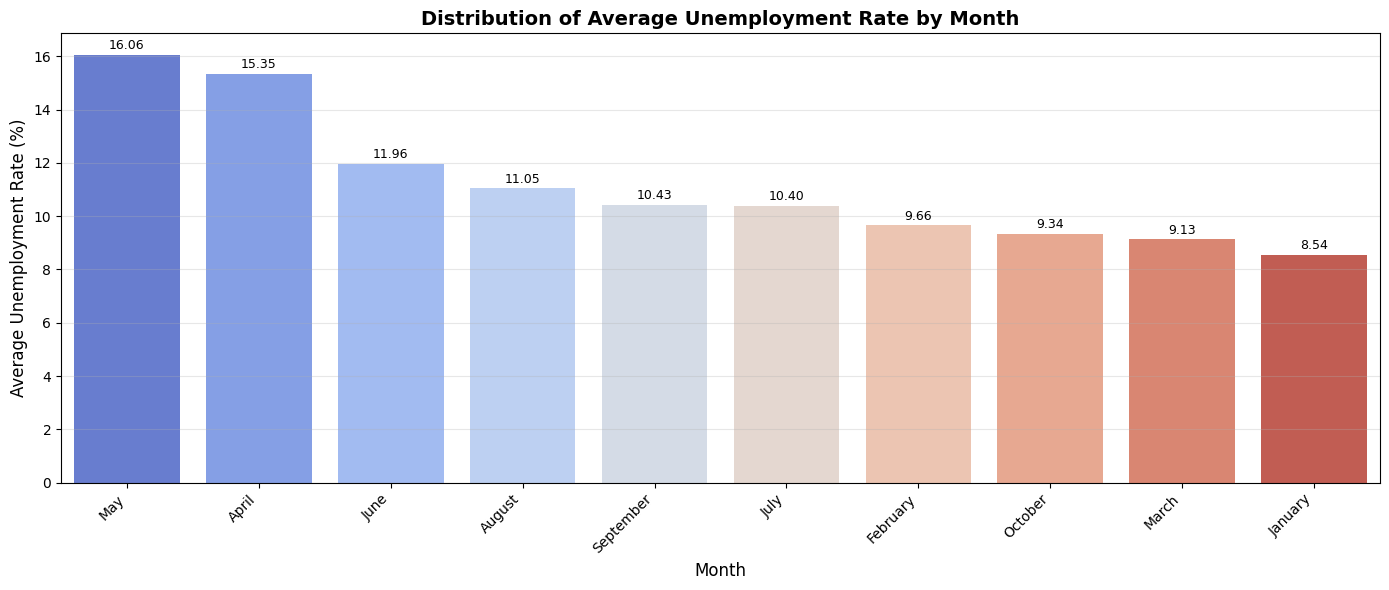

In [78]:
# Create bar graph for unemployment distribution by months
plt.figure(figsize=(14, 6))
sns.barplot(
    x=unemp_by_months_mean.index,
    y=unemp_by_months_mean.values,
    palette='coolwarm'
)

plt.title('Distribution of Average Unemployment Rate by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(unemp_by_months_mean.values):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Statistical Summary

In [79]:
print("The statistical summary of the unemployment rate is: ")
print(combined_unemp['Estimated Unemployment Rate (%)'].describe().T)

The statistical summary of the unemployment rate is: 
count    1007.000000
mean       11.906991
std        10.739549
min         0.000000
25%         4.685000
50%         8.890000
75%        16.125000
max        76.740000
Name: Estimated Unemployment Rate (%), dtype: float64


### Correlation Analysis

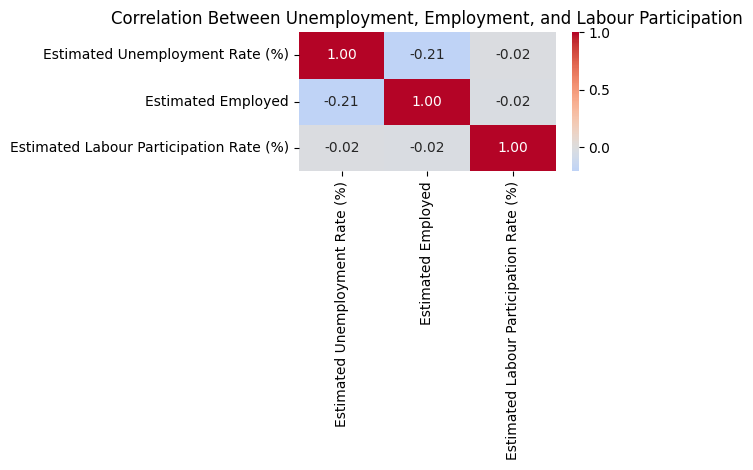

In [80]:
correlation_matrix = combined_unemp[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Unemployment, Employment, and Labour Participation')
plt.tight_layout()
plt.show()

### Distribution of Unemployment Rate

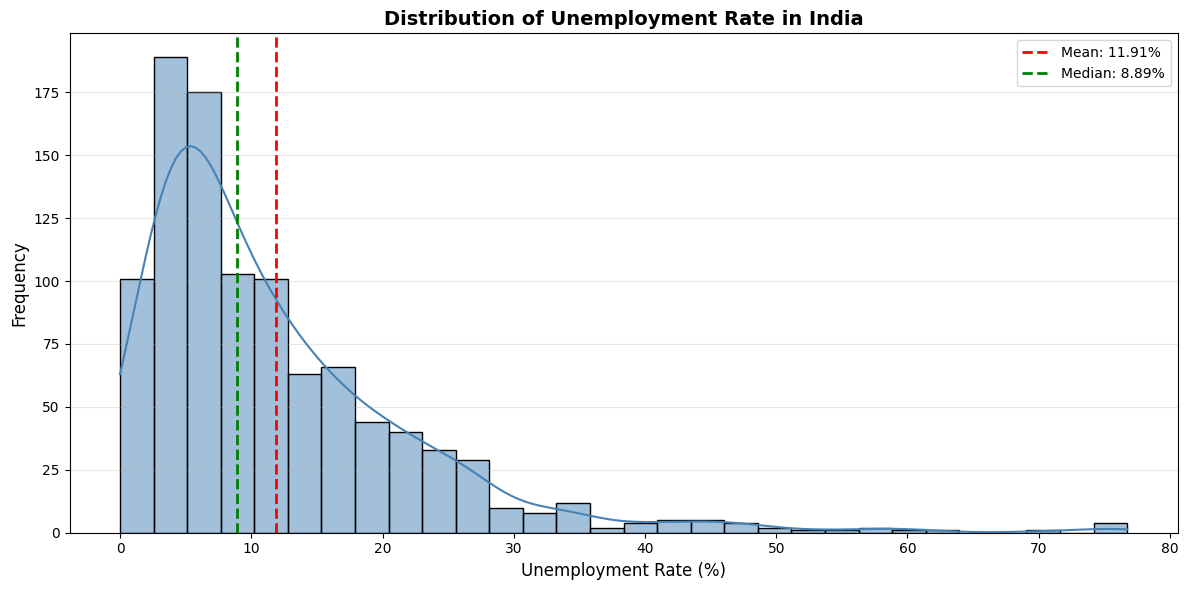

Mean Unemployment Rate: 11.91%
Median Unemployment Rate: 8.89%
Standard Deviation: 10.74%


In [81]:
# Create histogram for unemployment rate distribution
plt.figure(figsize=(12, 6))
sns.histplot(
    data=combined_unemp,
    x='Estimated Unemployment Rate (%)',
    kde=True,
    bins=30,
    color='steelblue',
    edgecolor='black'
)

plt.title('Distribution of Unemployment Rate in India', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add statistics
mean_unemp = combined_unemp['Estimated Unemployment Rate (%)'].mean()
median_unemp = combined_unemp['Estimated Unemployment Rate (%)'].median()
std_unemp = combined_unemp['Estimated Unemployment Rate (%)'].std()

plt.axvline(mean_unemp, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_unemp:.2f}%')
plt.axvline(median_unemp, color='green', linestyle='--', linewidth=2, label=f'Median: {median_unemp:.2f}%')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Mean Unemployment Rate: {mean_unemp:.2f}%")
print(f"Median Unemployment Rate: {median_unemp:.2f}%")
print(f"Standard Deviation: {std_unemp:.2f}%")

### Time Series Analysis for Top Regions

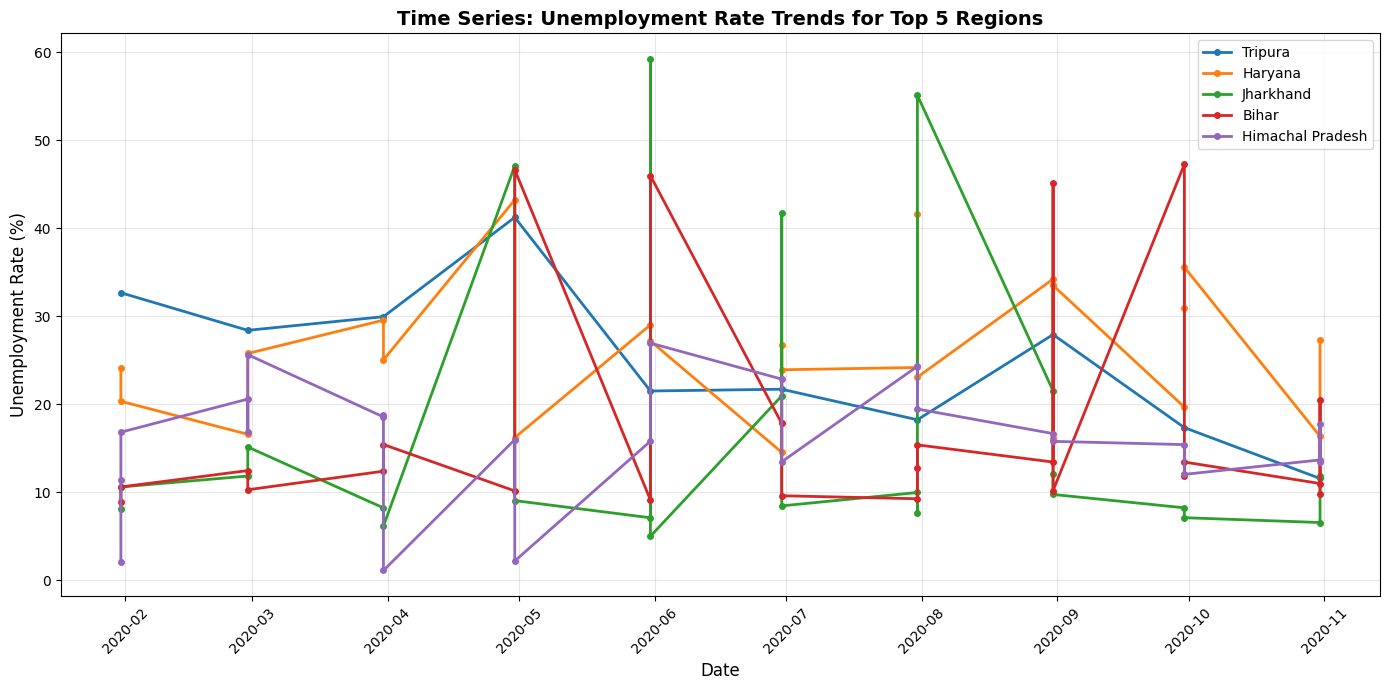

Top 5 Regions by Average Unemployment Rate:
1. Tripura: 27.48%
2. Haryana: 26.60%
3. Jharkhand: 20.31%
4. Bihar: 19.06%
5. Himachal Pradesh: 17.89%


In [82]:
# Get top 5 regions by average unemployment rate
top_5_regions = unemp_by_region_mean.head(5).index.tolist()

# Create time series plot for top regions
plt.figure(figsize=(14, 7))

for region in top_5_regions:
    region_data = combined_unemp[combined_unemp['Region'] == region].sort_values('Date')
    plt.plot(region_data['Date'], region_data['Estimated Unemployment Rate (%)'], 
             marker='o', label=region, linewidth=2, markersize=4)

plt.title('Time Series: Unemployment Rate Trends for Top 5 Regions', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Top 5 Regions by Average Unemployment Rate:")
for i, region in enumerate(top_5_regions, 1):
    print(f"{i}. {region}: {unemp_by_region_mean[region]:.2f}%")

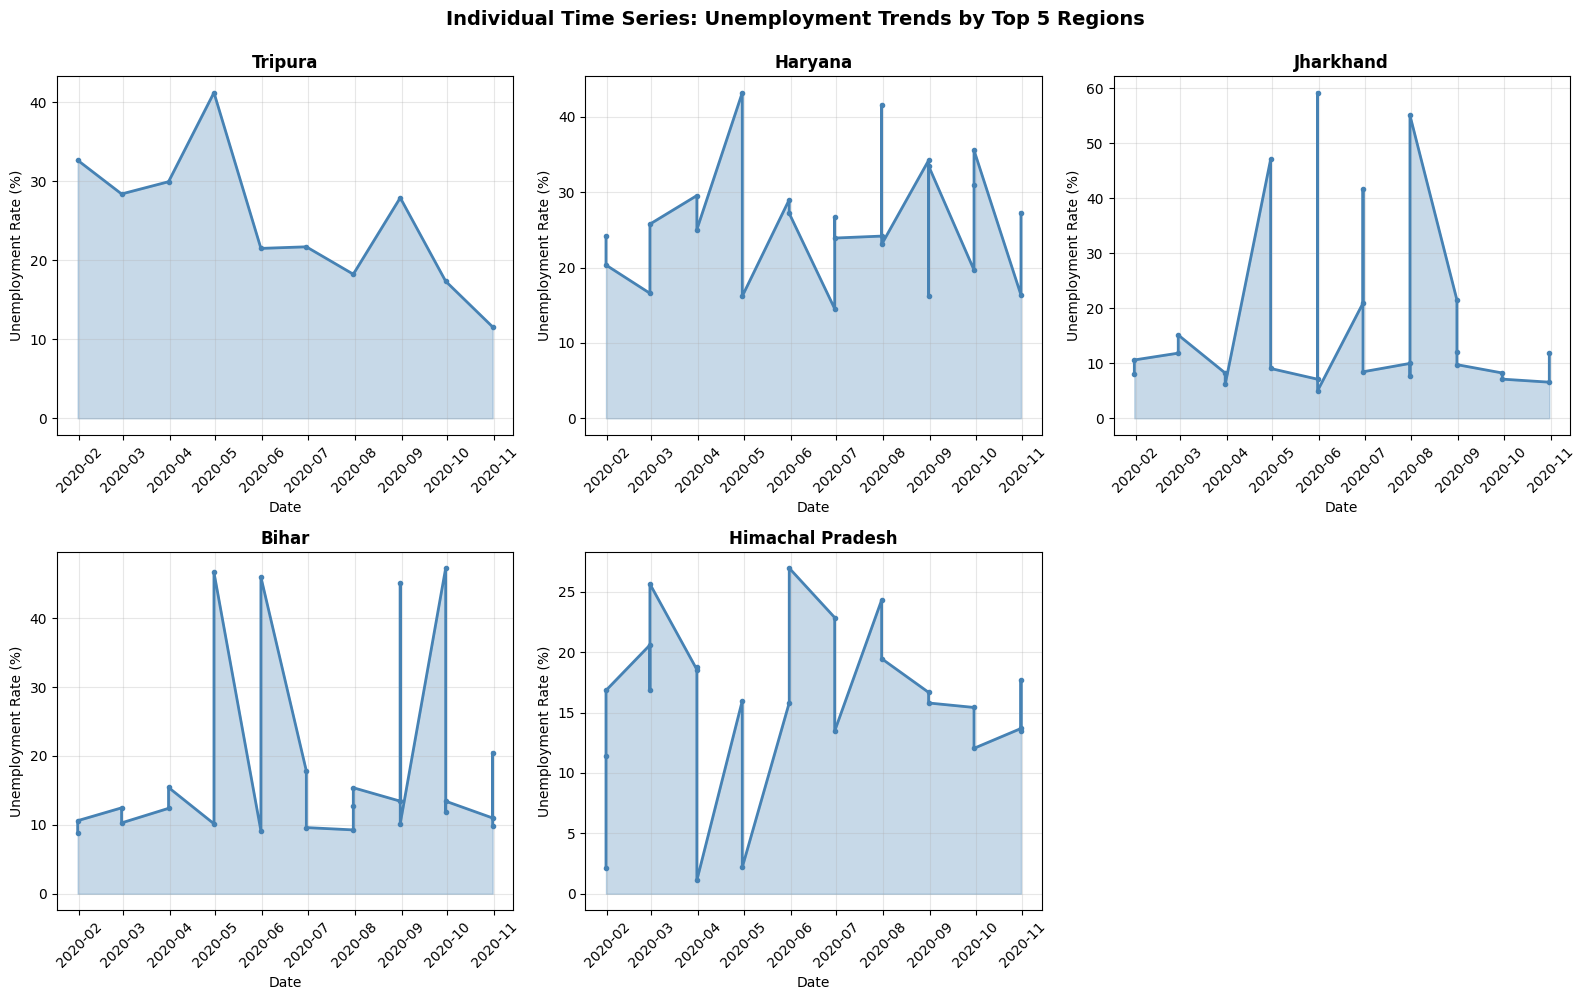

In [83]:
# Individual time series plots for each of the top 5 regions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, region in enumerate(top_5_regions):
    region_data = combined_unemp[combined_unemp['Region'] == region].sort_values('Date')
    
    axes[idx].plot(region_data['Date'], region_data['Estimated Unemployment Rate (%)'], 
                   color='steelblue', linewidth=2, marker='o', markersize=3)
    axes[idx].fill_between(region_data['Date'], region_data['Estimated Unemployment Rate (%)'], 
                           alpha=0.3, color='steelblue')
    axes[idx].set_title(f'{region}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date', fontsize=10)
    axes[idx].set_ylabel('Unemployment Rate (%)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

# Hide the extra subplot
axes[5].set_visible(False)

plt.suptitle('Individual Time Series: Unemployment Trends by Top 5 Regions', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Relationship Between Employment and Unemployment

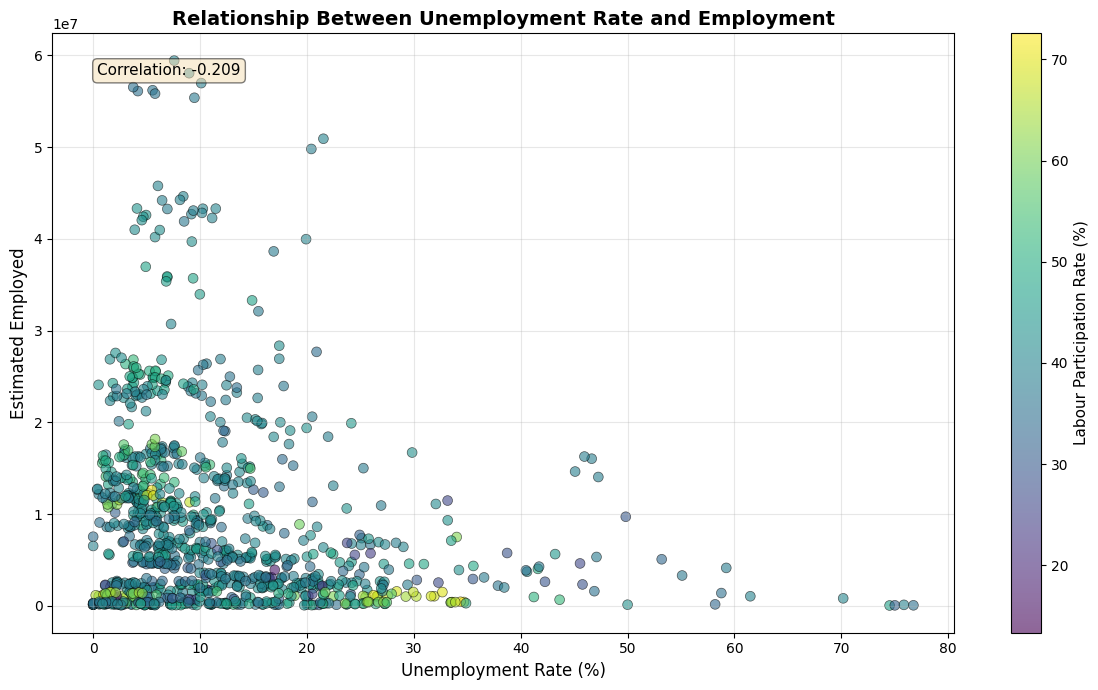

Correlation between Unemployment Rate and Employment: -0.2095

Interpretation: Weak negative correlation - Slight tendency for unemployment to decrease with employment


In [84]:
# Create scatter plot showing relationship between unemployment and employment
plt.figure(figsize=(12, 7))

# Scatter plot with color based on labour participation rate
scatter = plt.scatter(
    combined_unemp['Estimated Unemployment Rate (%)'],
    combined_unemp['Estimated Employed'],
    c=combined_unemp['Estimated Labour Participation Rate (%)'],
    cmap='viridis',
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

plt.xlabel('Unemployment Rate (%)', fontsize=12)
plt.ylabel('Estimated Employed', fontsize=12)
plt.title('Relationship Between Unemployment Rate and Employment', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Labour Participation Rate (%)', fontsize=11)

# Calculate and display correlation
correlation = combined_unemp['Estimated Unemployment Rate (%)'].corr(combined_unemp['Estimated Employed'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"Correlation between Unemployment Rate and Employment: {correlation:.4f}")
print(f"\nInterpretation: ", end="")
if correlation < -0.5:
    print("Strong negative correlation - Higher unemployment is associated with lower employment")
elif correlation < 0:
    print("Weak negative correlation - Slight tendency for unemployment to decrease with employment")
else:
    print("Positive correlation - Unusual pattern, may indicate other factors at play")

### Rural vs Urban Unemployment Comparison

<Figure size 1000x600 with 0 Axes>

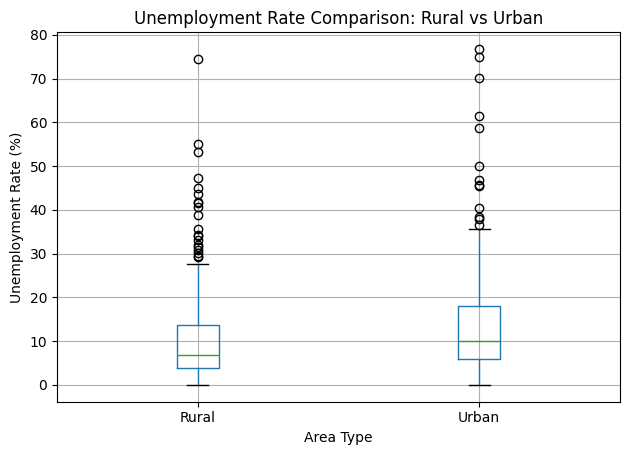

In [47]:
plt.figure(figsize=(10, 6))
combined_unemp.boxplot(column='Estimated Unemployment Rate (%)', by='Area')
plt.title('Unemployment Rate Comparison: Rural vs Urban')
plt.suptitle('')
plt.xlabel('Area Type')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.show()

## Key Findings & Conclusions

### Main Observations:

1. **Regional Disparities:**
   - Regions such as Tripura, Haryana, and Jharkhand exhibit the highest unemployment rates
   - Significant variation exists across different states in India

2. **Seasonal Patterns:**
   - The months from May-August experienced elevated unemployment rates
   - This period coincides with the impact of COVID-19 on employment
   - Unemployment follows a seasonal trend with peaks in April-May

3. **Employment Dynamics:**
   - Strong negative correlation between unemployment and employment rates
   - Labour participation rates show distinct patterns across regions
   - Rural-urban disparities are evident in unemployment trends

4. **Temporal Trends:**
   - Clear upward trend in unemployment during 2020
   - Recovery patterns vary across different regions
   - Post-monsoon months show different employment dynamics